#### Machine Learning - Based Labour Demand Prediction for New Zealand Workforce Planning
##### MBI806B: Business Data Analytics with Visualisation and Decision-Making
***By 270744391 - Nishadi Bamunuarachchi***

## Import Libraries ##

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.simplefilter(action='ignore')
from IPython.display import display, Markdown
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import sys
!{sys.executable} -m pip install xgboost lightgbm catboost
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

Defaulting to user installation because normal site-packages is not writeable


##  Load Dataset ##

In [3]:
occdf = pd.read_csv("Occupation_2018_2023.csv")

In [4]:
occdf.head(3)

,Census year,CEN23_GEO,Area,Island,CEN23_OCC,Occupation,CEN23_IND,Industry,CEN23_AGE,Age,Age Bucket,CEN23_GEN,Gender,OBS_VALUE,OBS_STATUS,Observation Status
0,2018,14,Otago Region,South Island,8,Labourers,M,"Professional, Scientific and Technical Services",14,65-69 years,65 years and over,2,Female / Wahine,9.0,NaN,NaN
1,2018,9,Wellington Region,North Island,8,Labourers,C,Manufacturing,8,35-39 years,30-64 years,3,Another gender / He ira kē anō,NaN,_U,Not available
2,2018,1,Northland Region,North Island,1,Managers,K,Financial and Insurance Services,4,15-19 years,15-29 years,3,Another gender / He ira kē anō,NaN,_U,Not available


## Data Preproceessing ##

### Data Quality Analysis ###

In [5]:
initial_rows, initial_cols = occdf.shape
print(f"Initial Rows = {initial_rows}, Initial Columns = {initial_cols}")

Initial Rows = 293760, Initial Columns = 16


In [6]:
print(list(occdf.columns))

['Census year', 'CEN23_GEO', 'Area', 'Island', 'CEN23_OCC', 'Occupation', 'CEN23_IND', 'Industry', 'CEN23_AGE', 'Age', 'Age Bucket', 'CEN23_GEN', 'Gender', 'OBS_VALUE', 'OBS_STATUS', 'Observation Status']


In [7]:
print("""
Descriptive Statistics Explanation for Numeric Columns:
-------------------------------------------------------
count  → Number of non-missing values in each column  
mean   → Average value  
std    → Standard deviation (spread of data)  
min    → Minimum value  
25%    → 1st quartile (25% of data below this value)  
50%    → Median (middle value)  
75%    → 3rd quartile (75% of data below this value)  
max    → Maximum value """)

occdf.describe()


Descriptive Statistics Explanation for Numeric Columns:
-------------------------------------------------------
count  → Number of non-missing values in each column  
mean   → Average value  
std    → Standard deviation (spread of data)  
min    → Minimum value  
25%    → 1st quartile (25% of data below this value)  
50%    → Median (middle value)  
75%    → 3rd quartile (75% of data below this value)  
max    → Maximum value 


,Census year,CEN23_GEO,CEN23_OCC,CEN23_AGE,CEN23_GEN,OBS_VALUE
count,293760.000000,293760.000000,293760.000000,293760.00000,293760.000000,217600.000000
mean,2020.500000,14.647059,5.000000,11.50000,2.000000,23.248346
std,2.500004,21.749793,2.581993,4.60978,0.816498,108.478401
min,2018.000000,1.000000,1.000000,4.00000,1.000000,0.000000
25%,2018.000000,5.000000,3.000000,7.75000,1.000000,0.000000
50%,2020.500000,9.000000,5.000000,11.50000,2.000000,0.000000
75%,2023.000000,15.000000,7.000000,15.25000,3.000000,9.000000
max,2023.000000,99.000000,9.000000,19.00000,3.000000,4983.000000


In [8]:
print("""
Descriptive Explanation for Categorical Columns:
------------------------------------------------------------
count   → Number of non-missing values  
unique  → Number of distinct categories  
top     → Most frequent category  
freq    → Frequency of the most common category""")

occdf.describe(include=['O'])


Descriptive Explanation for Categorical Columns:
------------------------------------------------------------
count   → Number of non-missing values  
unique  → Number of distinct categories  
top     → Most frequent category  
freq    → Frequency of the most common category


,Area,Island,Occupation,CEN23_IND,Industry,Age,Age Bucket,Gender,OBS_STATUS,Observation Status
count,293760,293760,293760,293760,293760,293760,293760,293760,76160,76160
unique,17,2,9,20,20,16,3,3,2,2
top,Otago Region,North Island,Labourers,M,"Professional, Scientific and Technical Services",65-69 years,30-64 years,Female / Wahine,_U,Not available
freq,17280,155520,32640,14688,14688,18360,128520,97920,48960,48960


In [9]:
print(""" 
Summary of the dataset:
-----------------------------------------------""")
occdf.info()

 
Summary of the dataset:
-----------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293760 entries, 0 to 293759
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Census year         293760 non-null  int64  
 1   CEN23_GEO           293760 non-null  int64  
 2   Area                293760 non-null  object 
 3   Island              293760 non-null  object 
 4   CEN23_OCC           293760 non-null  int64  
 5   Occupation          293760 non-null  object 
 6   CEN23_IND           293760 non-null  object 
 7   Industry            293760 non-null  object 
 8   CEN23_AGE           293760 non-null  int64  
 9   Age                 293760 non-null  object 
 10  Age Bucket          293760 non-null  object 
 11  CEN23_GEN           293760 non-null  int64  
 12  Gender              293760 non-null  object 
 13  OBS_VALUE           217600 non-null  float64
 14  OBS_STATUS

### Data Cleaning ###

****Dropping Columns with reference values.****

In [10]:
dropped_columns = ['CEN23_GEO', 'CEN23_OCC', 'CEN23_IND', 'CEN23_AGE', 'CEN23_GEN']
drop_columns_count = len(dropped_columns)
occdf.drop(columns=dropped_columns, inplace=True)

print("Dropped column Count  :", drop_columns_count)
print("Remaining column Count:", len(occdf.columns))
print("Remaining column Names:", list(occdf.columns))


Dropped column Count  : 5
Remaining column Count: 11
Remaining column Names: ['Census year', 'Area', 'Island', 'Occupation', 'Industry', 'Age', 'Age Bucket', 'Gender', 'OBS_VALUE', 'OBS_STATUS', 'Observation Status']


****Dropping NULL Values.****

In [11]:
before_dropna_rows = occdf.shape[0]
occdf.dropna(subset=['OBS_VALUE'], inplace=True)
after_dropna_rows = occdf.shape[0]
dropped_na_count = before_dropna_rows - after_dropna_rows

print(""" 
Summary of dataset after removing NULL in OBS_VALUE:
----------------------------------------------------""")

print(f"Rows before dropna : {before_dropna_rows}")
print(f"Rows after dropna  : {after_dropna_rows}")
print(f"Total rows removed : {dropped_na_count}")

occdf.info()

 
Summary of dataset after removing NULL in OBS_VALUE:
----------------------------------------------------
Rows before dropna : 293760
Rows after dropna  : 217600
Total rows removed : 76160
<class 'pandas.core.frame.DataFrame'>
Index: 217600 entries, 0 to 293758
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Census year         217600 non-null  int64  
 1   Area                217600 non-null  object 
 2   Island              217600 non-null  object 
 3   Occupation          217600 non-null  object 
 4   Industry            217600 non-null  object 
 5   Age                 217600 non-null  object 
 6   Age Bucket          217600 non-null  object 
 7   Gender              217600 non-null  object 
 8   OBS_VALUE           217600 non-null  float64
 9   OBS_STATUS          0 non-null       object 
 10  Observation Status  0 non-null       object 
dtypes: float64(1), int64(1), object(9)
memory usage:

****Dropping Unwanted Columns.****

In [12]:
before_drop_cols_count = occdf.shape[1]

cols_to_drop = ['OBS_STATUS', 'Observation Status']
occdf.drop(columns=cols_to_drop, inplace=True)

after_drop_cols_count = occdf.shape[1]
after_drop_cols_list = list(occdf.columns)
dropped_cols_count = before_drop_cols_count - after_drop_cols_count

print("""
Summary of column removal:
-----------------------------------------------------------
""")

print(f"Columns before removal  : {before_drop_cols_count}")
print(f"Columns after removal   : {after_drop_cols_count}")
print(f"Columns removed         : {dropped_cols_count}")
print(f"Remaining columns       : {after_drop_cols_list}")


Summary of column removal:
-----------------------------------------------------------

Columns before removal  : 11
Columns after removal   : 9
Columns removed         : 2
Remaining columns       : ['Census year', 'Area', 'Island', 'Occupation', 'Industry', 'Age', 'Age Bucket', 'Gender', 'OBS_VALUE']


****Renaming Columns for ease.****

In [13]:
occdf = occdf.rename(columns={
    'Census year': 'census_year',
    'Area': 'area',
    'Island': 'island',
    'Occupation': 'occupation',
    'Industry': 'industry',
    'Age': 'age',
    'Age Bucket': 'age_group',
    'Gender': 'gender',
    'OBS_VALUE': 'labour_demand'
})
print(list(occdf.columns))  

['census_year', 'area', 'island', 'occupation', 'industry', 'age', 'age_group', 'gender', 'labour_demand']


****Correction of Inconsistent Naming Values - (English + Māori text)****

In [14]:
cat_cols = occdf.select_dtypes(include='object').columns 

for col in cat_cols: 
    print("\nColumn:", col) 
    print(occdf[col].unique())


Column: area
['Otago Region' 'Waikato Region' 'Nelson Region' 'Taranaki Region'
 'Canterbury Region' "Hawke's Bay Region" 'Auckland Region'
 'Manawatū-Whanganui\xa0Region' 'Wellington Region' 'Tasman Region'
 'Marlborough Region' 'West Coast Region' 'Bay of Plenty Region'
 'Northland Region' 'Southland Region' 'Gisborne Region'
 'Area Outside Region']

Column: island
['South Island' 'North Island']

Column: occupation
['Labourers' 'Sales Workers' 'Clerical and Administrative Workers'
 'Residual Categories (Operational Codes only)'
 'Technicians and Trades Workers' 'Professionals' 'Managers'
 'Community and Personal Service Workers'
 'Machinery Operators and Drivers']

Column: industry
['Professional, Scientific and Technical Services' 'Mining'
 'Rental, Hiring and Real Estate Services'
 'Public Administration and Safety' 'Financial and Insurance Services'
 'Arts and Recreation Services' 'Construction' 'Retail Trade'
 'Other Services' 'Information Media and Telecommunications'
 'Not El

***Correction of Inconsistent Naming in 'Manawatū-Whanganui\xa0Regio', Gender and Area Values***

In [15]:
before_area = occdf['area'].copy()
before_gender = occdf['gender'].copy()
before_occupation = occdf['occupation'].copy()

In [16]:
occdf['area'] = occdf['area'].replace({'Manawatū-Whanganui\xa0Region': 'Manawatu-Whanganui Region'})
occdf['gender'] = occdf['gender'].replace({'Female / Wahine': 'Female','Male / Tāne': 'Male','Another gender / He ira kē anō': 'Other'})
occdf['occupation'] = occdf['occupation'].replace({'Residual Categories (Operational Codes only)': 'Residual Categories'})

In [17]:
area_corrected = (before_area != occdf['area']).sum()
gender_corrected = (before_gender != occdf['gender']).sum()
occupation_corrected = (before_occupation != occdf['occupation']).sum()

In [18]:
print("""
Inconsistent Naming Correction Summary:
--------------------------------------------------------------
""")

print(f"Area values corrected       : {area_corrected}")
print(f"Gender values corrected     : {gender_corrected}")
print(f"Occupation values corrected : {occupation_corrected}")


Inconsistent Naming Correction Summary:
--------------------------------------------------------------

Area values corrected       : 14400
Gender values corrected     : 217600
Occupation values corrected : 24000


****Outlier Detection and Analysis.****

***Statistical outlier detection using IQR method.***

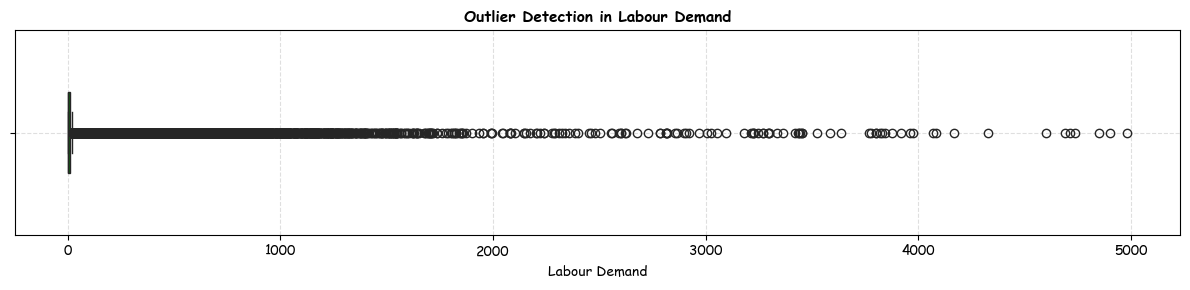

In [19]:
# Illustrating a boxplot for column "labour_demand" to understand the spread of data points.

plt.figure(figsize=(12, 3))
plt.rcParams.update({"font.family": "Comic Sans MS"})

ax = sns.boxplot(x=occdf["labour_demand"],color="green",width=0.4)
ax.set_title("Outlier Detection in Labour Demand",fontsize=11,fontweight="bold")
ax.set_xlabel("Labour Demand",fontsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [20]:
# Capturing outliers in labour_demand

def capture_outliers(col_name, df_in):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = (df_in[col_name] < lower_bound) | (df_in[col_name] > upper_bound)
    df_out = df_in.loc[outliers]

    return df_out

out = capture_outliers('labour_demand', occdf)
print("Number of outliers:", len(out))

Number of outliers: 34754


In [21]:
out.describe()

,census_year,labour_demand
count,34754.000000,34754.000000
mean,2020.637107,130.797548
std,2.496273,244.505401
min,2018.000000,24.000000
25%,2018.000000,36.000000
50%,2023.000000,60.000000
75%,2023.000000,123.000000
max,2023.000000,4983.000000


### **Note:**
**Outliers have been identified using the IQR method.
However, they are retained in the dataset as they are considered meaningful observations representing real-world variations in labour demand, particularly in high-demand occupations and time periods.Therefore, no outlier removal has been performed.**

In [22]:
occdf_cleaned = occdf.copy()

In [23]:
audit_table = pd.DataFrame({
    "Metric": [
        "Initial Rows",
        "Initial Columns",
        "Total Rows Removed",
        "Total Columns Removed",
        "Total Area Values Corrected",
        "Total Gender Values Corrected",
        "Total Occupation Values Corrected",
        "Total Outliers Identified",
        "Final Dataset Rows",
        "Final Dataset Columns"
    ],
    "Value": [
        initial_rows,
        initial_cols,
        dropped_na_count,
        drop_columns_count + dropped_cols_count,
        area_corrected,
        gender_corrected,
        occupation_corrected,
        len(out),
        occdf_cleaned.shape[0],
        occdf_cleaned.shape[1]
    ]
})

audit_table = audit_table[['Metric', 'Value']]
audit_table['Value'] = audit_table['Value'].apply(lambda x: f"{x:,}" if isinstance(x, (int, float)) else x)

display(Markdown("<span style='font-size:13px; font-weight:bold;'>Data Cleaning and Preprocessing Audit Report</span>"))
audit_table

<span style='font-size:13px; font-weight:bold;'>Data Cleaning and Preprocessing Audit Report</span>

,Metric,Value
0,Initial Rows,"293,760"
1,Initial Columns,16
2,Total Rows Removed,"76,160"
3,Total Columns Removed,7
4,Total Area Values Corrected,"14,400"
5,Total Gender Values Corrected,"217,600"
6,Total Occupation Values Corrected,"24,000"
7,Total Outliers Identified,"34,754"
8,Final Dataset Rows,"217,600"
9,Final Dataset Columns,9


***Exporting Cleaned Data to CSV***

In [24]:
occdf_cleaned.to_csv("occdf_cleaned.csv", index=False)
audit_table.to_csv("audit_table.csv", index=False)

## Exploratory Data Analysis ##

**1. National Labour Demand - 2018 vs 2023**

In [25]:
occdf_cl = occdf.copy()

In [26]:
by_year = occdf_cl.groupby('census_year')['labour_demand'].sum().reset_index()
by_year

,census_year,labour_demand
0,2018,2440785.0
1,2023,2618055.0


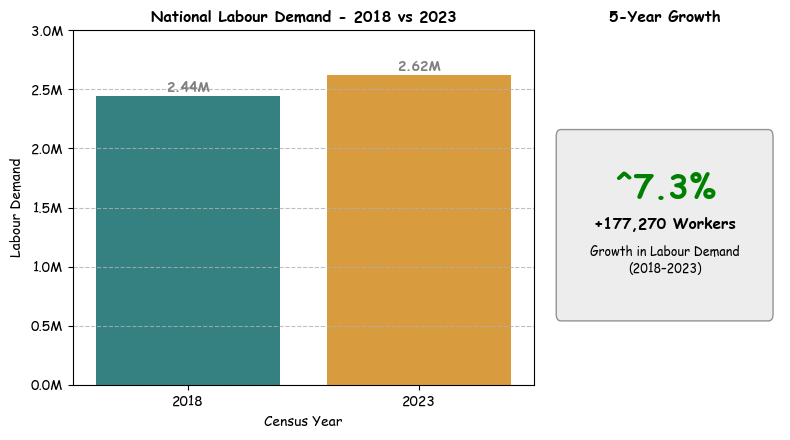

In [127]:
# SUBPLOT ============================================================================================

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(8, 4.5),gridspec_kw={'width_ratios': [2, 1]})

# BAR CHART ==========================================================================================

ax = sns.barplot(data=by_year,x='census_year',y='labour_demand',palette=['#298C8C','#F1A226'],ax=ax1)

# Format Y-axis to Millions
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Formatting bar lables
for container in ax.containers:
    ax1.bar_label(container,
                 labels=[f"{v/1e6:.2f}M" for v in container.datavalues],
                 fontsize=10,
                 fontweight="bold",
                 color="grey")

ax1.set_title('National Labour Demand - 2018 vs 2023', fontsize=11,fontweight="bold")
ax1.set_xlabel('Census Year',fontsize=10)
ax1.set_ylabel('Labour Demand',fontsize=10)

ax1.set_ylim(0, 3_000_000)
ax1.tick_params(axis='x',labelsize=10)
ax1.tick_params(axis='y',labelsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.8)


# KPI =================================================================================================
card = FancyBboxPatch((0.05,0.2), 0.9, 0.5,boxstyle="round,pad=0.02",facecolor="lightgray",alpha=0.4,linewidth=1,transform=ax2.transAxes)
ax2.add_patch(card)

increase = by_year.loc[1, 'labour_demand'] - by_year.loc[0, 'labour_demand']
growth_pct = (increase / by_year.loc[0, 'labour_demand']) * 100

ax2.text(0.5, 0.55,f"^{growth_pct:.1f}%",ha='center',va='center',fontsize=24,fontweight='bold',color='green')

ax2.text(0.5, 0.45,f"+{increase:,.0f} Workers",ha='center',va='center',fontsize=11,fontweight='bold')

ax2.text(0.5, 0.35,"Growth in Labour Demand\n(2018–2023)",ha='center',va='center',fontsize=9)

ax2.set_title('5-Year Growth', fontsize=11,fontweight="bold")

ax2.axis('off')
plt.tight_layout()
fig.savefig("1.National_Labour_demand_KPI.png",dpi=300,bbox_inches="tight",facecolor=fig.get_facecolor())
plt.show()


**2. Labour Demand by Occupation - 2018 vs 2023**

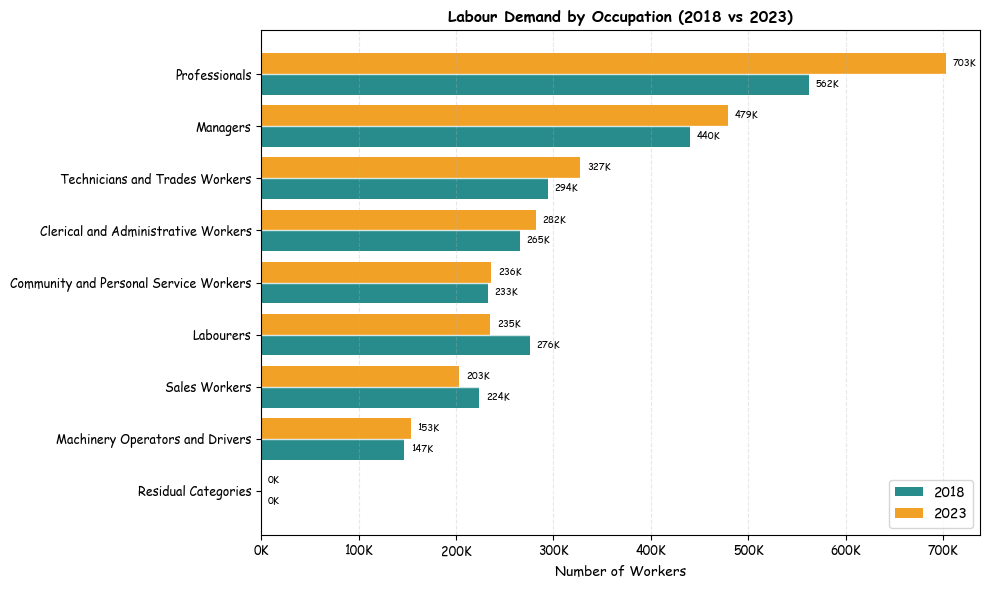

In [128]:
years = [2018, 2023]

occ = (occdf_cl[occdf_cl['census_year'].isin(years)].groupby(['occupation', 'census_year'])['labour_demand'].sum().reset_index())

occ_pivot = occ.pivot(index='occupation', columns='census_year', values='labour_demand')
occ_pivot = occ_pivot.sort_values(by=2023)

y = np.arange(len(occ_pivot.index))
height=0.4

plt.figure(figsize=(10,6))

bars1 = plt.barh(y - height/2,occ_pivot[2018],height=height,label='2018',color='#298C8C')
bars2 = plt.barh(y + height/2,occ_pivot[2023],height=height,label='2023',color='#F1A226')

# Space between Bars
for i in range(len(occ_pivot.index)):
    plt.axhline(y=i,color='white',linewidth=1,alpha=0.8)
    
txtspace = occ_pivot.values.max() * 0.01

for bar in bars1:
    plt.text(
        bar.get_width()+txtspace,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width()/1000:,.0f}K",
        va='center',
        fontsize=7)

for bar in bars2:
    plt.text(
        bar.get_width()+txtspace,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width()/1000:,.0f}K",
        va='center',
        fontsize=7)
plt.yticks(y, occ_pivot.index)

plt.tick_params(axis='x',labelsize=9)
plt.tick_params(axis='y',labelsize=9)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.xlabel("Number of Workers",fontsize=10)
plt.title("Labour Demand by Occupation (2018 vs 2023)",fontsize=11,fontweight="bold")
plt.legend(loc='lower right')


plt.tight_layout()
plt.savefig("2.Labour Demand by Occupation_2018_2023.png", dpi=300)
plt.show()


**3. Labour Demand % Change by Occupation - 2018 vs 2023**

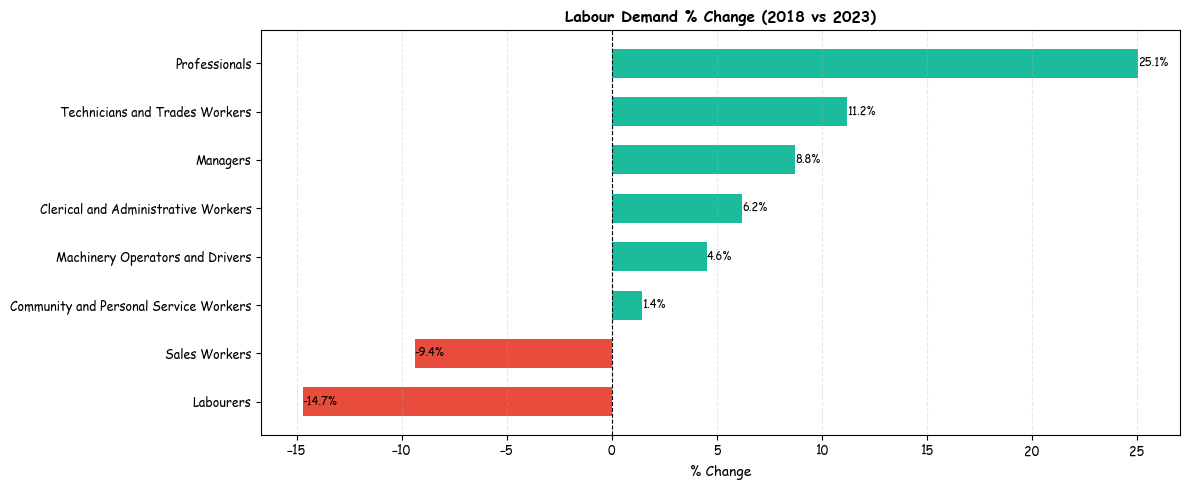

In [129]:
# Filter data
occfilrdf = occdf_cl[(occdf_cl['census_year'].isin([2018, 2023])) &(occdf_cl['occupation'] != 'Residual Categories')]
occ = occfilrdf.groupby(['occupation', 'census_year'])['labour_demand'].sum().reset_index()

# Pivot
pivot = occ.pivot(index='occupation', columns='census_year', values='labour_demand')

# Ensure no divide-by-zero issues
baseyr = pivot[2018].replace(0, np.nan)
newyr = pivot[2023]

pct_change = ((newyr - baseyr) / baseyr) * 100

# Remove NaN and sort
pct_change = pct_change.dropna().sort_values()

# Y positions (FIXED)
y = np.arange(len(pct_change))
h = 0.6

# Colors
colors = ['#1ABC9C' if x > 0 else '#E74C3C' for x in pct_change]

plt.figure(figsize=(12, 5))
plt.barh(y, pct_change.values, height= h,color=colors)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Bar Labels
for i, v in enumerate(pct_change.values):
    plt.text(v, i, f"{v:.1f}%", va='center', fontsize=8)

plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.yticks(y, pct_change.index)
plt.xlabel("% Change", fontsize=10)
plt.tick_params(axis='x', labelsize=9)
plt.tick_params(axis='y', labelsize=9)

plt.title("Labour Demand % Change (2018 vs 2023)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("3.Labour Demand % Change.png", dpi=300)
plt.show()

**4. Top 10 Industries by Labour Demand (2018 vs 2023)**

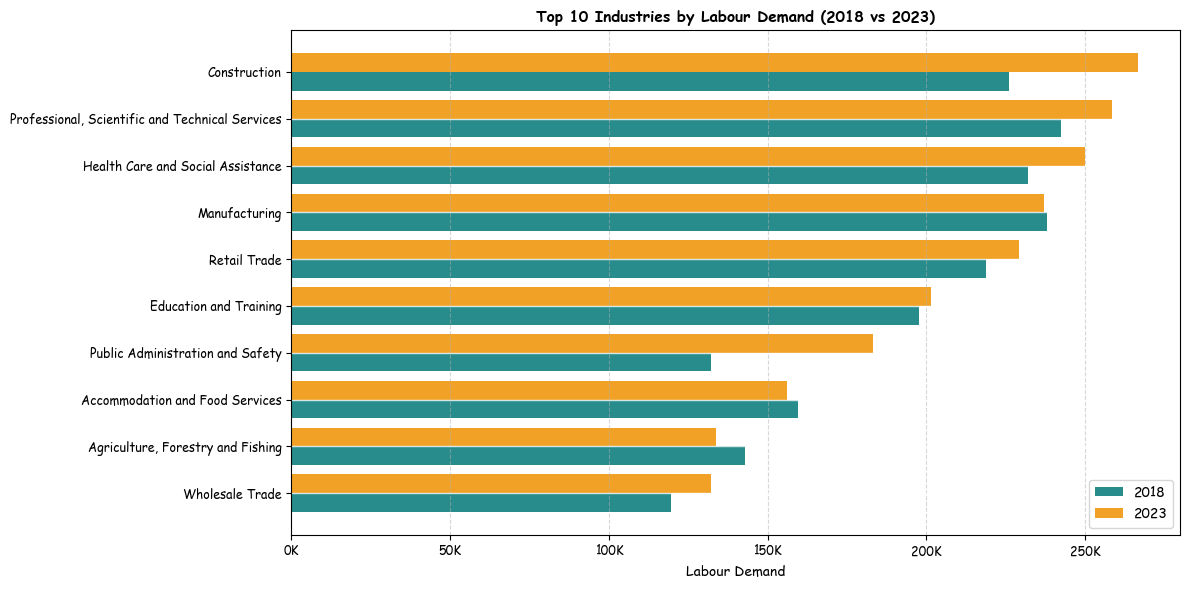

In [158]:
industrydf = (occdf_cl.groupby(['census_year','industry'])['labour_demand'].sum().reset_index())

ind_pivot = industrydf.pivot(index='industry', columns='census_year', values='labour_demand')

# Top 10 industries (Ranked based on 2023)
top10 = ind_pivot.nlargest(10, 2023).sort_values(2023, ascending=True)

y = np.arange(len(top10))
h= 0.4

plt.figure(figsize=(12, 6))

# Bars
bars1 = plt.barh(y - h/2, top10[2018], height=h, color='#298C8C', label='2018')
bars2 = plt.barh(y + h/2, top10[2023], height=h, color='#F1A226', label='2023')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Space between Bars
for i in range(len(occ_pivot.index)):
    plt.axhline(y=i,color='white',linewidth=1,alpha=0.8)

# Labels
plt.yticks(y, top10.index, fontsize=9)
plt.xlabel('Labour Demand')
plt.tick_params(axis='x',labelsize=9)
plt.tick_params(axis='y',labelsize=9)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.title('Top 10 Industries by Labour Demand (2018 vs 2023)', fontweight='bold',fontsize=11)
plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig("4.Top 10 Industries by Labour Demand.png", dpi=300)
plt.show()

**5. Labour Demand Growth by NZ Region (2018 vs 2023)**

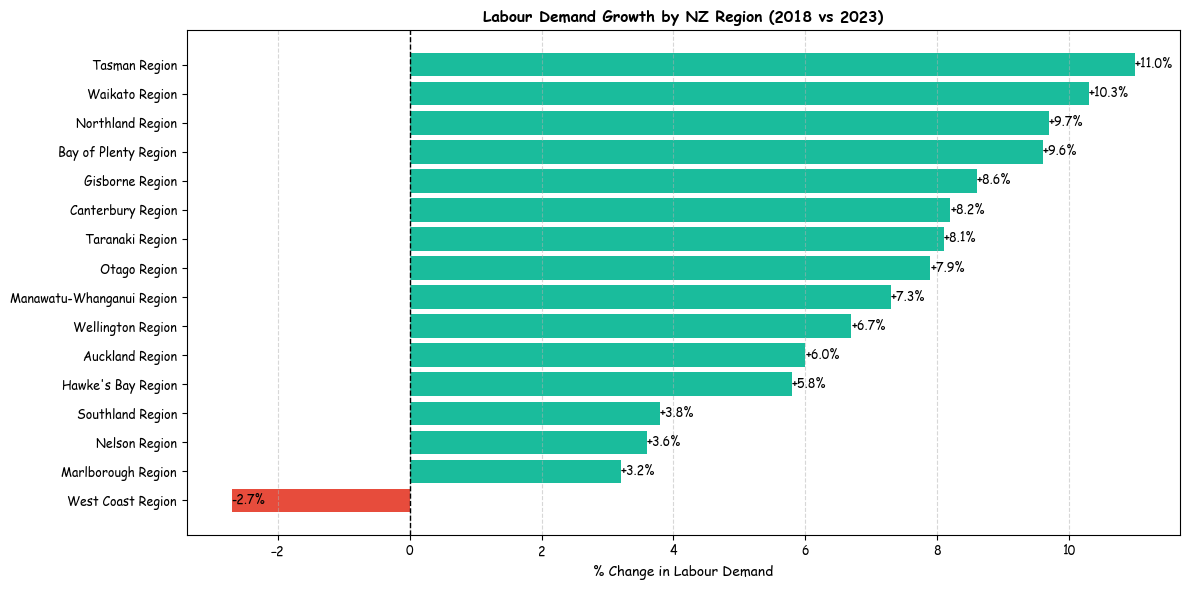

In [31]:
regdf = (occdf_cl[occdf_cl['area'] != 'Area Outside Region'].groupby(['census_year', 'area'])['labour_demand'].sum().reset_index())
reg_pivot = regdf.pivot(index='area', columns='census_year', values='labour_demand')

#  Growth % (safe calculation)
reg_pivot['pct_change'] = ((reg_pivot[2023] - reg_pivot[2018]) /reg_pivot[2018].replace(0, np.nan) * 100).round(1)
reg_pivot = reg_pivot.dropna(subset=['pct_change'])

reg_pivot = reg_pivot.sort_values('pct_change')

plt.figure(figsize=(12, 6))
colors = ['#E74C3C' if x < 0 else '#1ABC9C' for x in reg_pivot['pct_change']]

bars = plt.barh(reg_pivot.index,reg_pivot['pct_change'],color=colors)
plt.axvline(0, linestyle='--', color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# --- Labels ---
for bar, val in zip(bars, reg_pivot['pct_change']):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{val:+.1f}%",
        va='center',
        fontsize=9)
  
plt.xlabel('% Change in Labour Demand')
plt.tick_params(axis='x',labelsize=9)
plt.tick_params(axis='y',labelsize=9)

plt.title('Labour Demand Growth by NZ Region (2018 vs 2023)', fontweight='bold',fontsize=11)
plt.tight_layout()
plt.savefig("5.Labour Demand Growth by NZ Region.png", dpi=300)
plt.show()

**6. Labour Demand by Gender - 2018 vs 2023)**

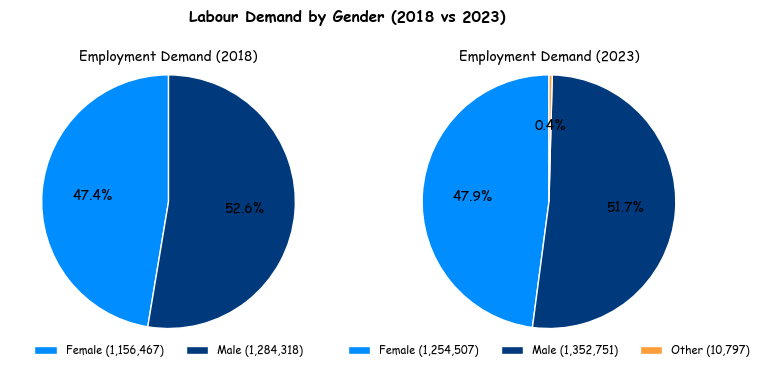

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(9,5))

colors = ['#008DFF','#003A7D','#FF9D3A']

for ax, year in zip(axes, [2018, 2023]):

    gender = (occdf_cl[occdf_cl['census_year'] == year].groupby('gender')['labour_demand'].sum())

    # Pie Chart
    
    ax.pie(
        gender.values,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1)
    )

    # Legend with values
    legend_labels = [
        f"{g} ({v:,.0f})"
        for g, v in zip(gender.index, gender.values)
    ]

    ax.legend(
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5,-0.02),
        ncol=3,
        frameon=False,
        fontsize=8
    )

    ax.set_title(f'Employment Demand ({year})',fontsize=10, y=0.92)

plt.suptitle('Labour Demand by Gender (2018 vs 2023)', fontweight='bold',fontsize=11,y=0.88)
plt.savefig('6.Labour Demand by Gender.png', dpi=120)
plt.show()



**7. Labour Demand by 5-Year Age Band Category**

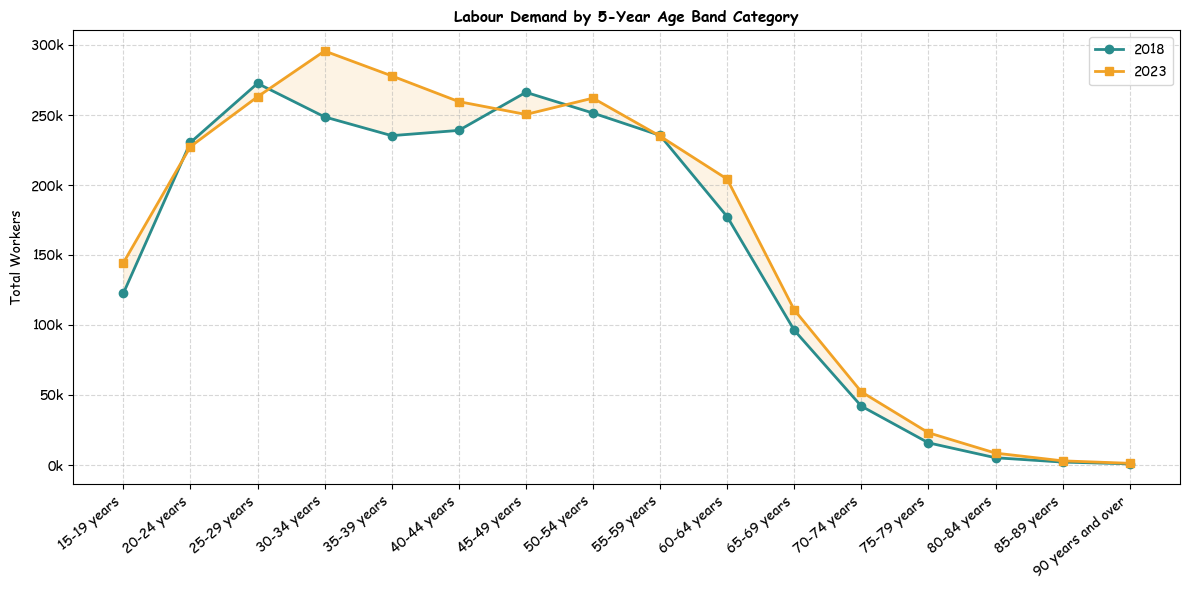

In [132]:
age_dmd = (occdf_cl.groupby(['census_year','age'])['labour_demand'].sum().reset_index())

age_order = ['15-19 years','20-24 years','25-29 years','30-34 years','35-39 years',
             '40-44 years','45-49 years','50-54 years','55-59 years','60-64 years',
             '65-69 years','70-74 years','75-79 years','80-84 years','85-89 years',
             '90 years and over']

age_dmd['age'] = pd.Categorical(age_dmd['age'], categories=age_order, ordered=True)
age_dmd = age_dmd.sort_values('age')

age_pivot = age_dmd.pivot(index='age', columns='census_year', values='labour_demand')

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(age_pivot.index, age_pivot[2018],marker='o', color='#298C8C', linewidth=2, markersize=6, label='2018')
ax.plot(age_pivot.index, age_pivot[2023],marker='s', color='#F1A226', linewidth=2, markersize=6, label='2023')
ax.grid(axis='x',linestyle='--', alpha=0.5)
ax.grid(axis='y',linestyle='--', alpha=0.5)

ax.fill_between(age_pivot.index,
                age_pivot[2018],
                age_pivot[2023],
                alpha=0.12,
                color= '#F1A226')

ax.set_xticklabels(age_pivot.index, rotation=40, ha='right')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))

ax.set_ylabel('Total Workers',fontsize=10)
ax.set_title('Labour Demand by 5-Year Age Band Category',fontweight='bold',fontsize=11)
ax.tick_params(axis='x',labelsize=10)
ax.tick_params(axis='y',labelsize=10)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("7.Labour Demand by 5-Year Age Band Category.png", dpi=300)
plt.show()


**8. Labour Demand Heatmap - Occupation × Industry (2023)**

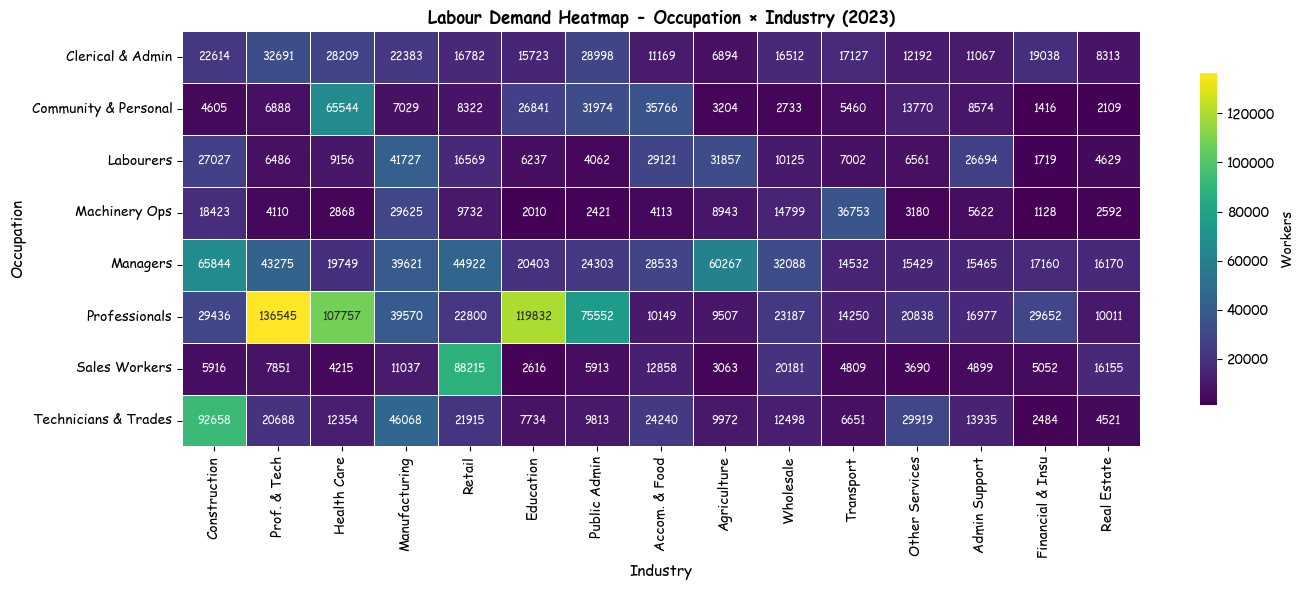

In [133]:
heat = (occdf_cl.query("census_year == 2023").groupby(['occupation', 'industry'])['labour_demand'].sum().unstack(fill_value=0)
      .drop(index='Residual Categories', errors='ignore'))

# Selecting TOP 15 Industries Only 
heat = heat.loc[:, heat.sum().nlargest(15).index]

# Renaming due to Length
heat = heat.rename(index={
    'Clerical and Administrative Workers': 'Clerical & Admin',
    'Community and Personal Service Workers': 'Community & Personal',
    'Machinery Operators and Drivers': 'Machinery Ops',
    'Technicians and Trades Workers': 'Technicians & Trades',
}).rename(columns={
    'Professional, Scientific and Technical Services': 'Prof. & Tech',
    'Health Care and Social Assistance': 'Health Care',
    'Public Administration and Safety': 'Public Admin',
    'Accommodation and Food Services': 'Accom. & Food',
    'Agriculture, Forestry and Fishing': 'Agriculture',
    'Transport, Postal and Warehousing': 'Transport',
    'Education and Training': 'Education',
    'Administrative and Support Services': 'Admin Support',
    'Retail Trade': 'Retail',
    'Manufacturing': 'Manufacturing',
    'Construction': 'Construction',
    'Wholesale Trade': 'Wholesale',
    'Financial and Insurance Services':'Financial & Insu',
    'Rental, Hiring and Real Estate Services':'Real Estate'
    
})

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    heat,
    annot=True, fmt='.0f',
    cmap='viridis',
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Workers', 'shrink': 0.8},
    ax=ax
)

ax.set_ylabel('Occupation',fontsize=11)
ax.set_xlabel('Industry',fontsize=11)
ax.set_title('Labour Demand Heatmap - Occupation × Industry (2023)',fontweight='bold',fontsize=12)
ax.tick_params(axis='x',labelsize=10)
ax.tick_params(axis='y',labelsize=10)


plt.tight_layout()
plt.savefig('8.Labour Demand Heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## Data Encoding for Model Buidling

In [35]:
occdf_fl = occdf.copy()

***Split by time***

In [36]:
train_df = occdf_fl[occdf_fl['census_year'] == 2018].copy()
test_df  = occdf_fl[occdf_fl['census_year'] == 2023].copy()

X_train = train_df.drop('labour_demand', axis=1)
y_train = train_df['labour_demand']

X_test = test_df.drop('labour_demand', axis=1)
y_test = test_df['labour_demand']

***Encoding Categorical Variables - One-Hot Encoding***

In [37]:
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

***View Encoded Values - If needs to view the result after encoding***

In [38]:
# Fit and transform training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Get new column names
encoded_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)

# Combine encoded categorical columns + numerical columns
all_cols = list(encoded_cols) + list(num_cols)

# Convert to DataFrame
X_train_encoded_df = pd.DataFrame(
    X_train_encoded.toarray() if hasattr(X_train_encoded, "toarray") else X_train_encoded,
    columns=all_cols,
    index=X_train.index
)

# Display first few rows
X_train_encoded_df.head(3)

,area_Area Outside Region,area_Auckland Region,area_Bay of Plenty Region,area_Canterbury Region,area_Gisborne Region,area_Hawke's Bay Region,area_Manawatu-Whanganui Region,area_Marlborough Region,area_Nelson Region,area_Northland Region,...,age_75-79 years,age_80-84 years,age_85-89 years,age_90 years and over,age_group_15-29 years,age_group_30-64 years,age_group_65 years and over,gender_Female,gender_Male,census_year
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2018.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2018.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2018.0


In [39]:
model_results = []   # Creating a empty list to store model results.

## Model Building - Approach 1

### 1. Decision Tree

In [41]:
dt_model = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))])

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_mae  = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2   = r2_score(y_test, dt_pred)

print("\nDecision Tree Results")
print(f"MAE:  {dt_mae:.3f}")
print(f"RMSE: {dt_rmse:.3f}")
print(f"R2:   {dt_r2:.3f}")


Decision Tree Results
MAE:  14.773
RMSE: 74.033
R2:   0.459


In [42]:
model_results.append({
    'Model': 'Decision Tree',
    'MAE': dt_mae,
    'RMSE': dt_rmse,
    'R2': dt_r2
})

dt_results = test_df.copy()
dt_results['pred_labour_demand'] = dt_pred
dt_results.to_csv("1.Decision_tree.csv", index=False)

In [43]:
y_test.mean() #MAE is small releveant to Mean - Good

20.06941356841702

### 2. Decision Tree
***Hyperparameter Tuned - GrdidSearch Model***

In [45]:
dt_model_hy = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_grid = {
    'model__max_depth': [3, 5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 3, 5, 10],
    'model__criterion': ['squared_error', 'friedman_mse']
}

grid_search = GridSearchCV(
    dt_model_hy,
    param_grid,
    cv=5,
    scoring='r2',   # you can also use 'neg_mean_absolute_error'
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_dt_model = grid_search.best_estimator_

dt_pred = best_dt_model.predict(X_test)

dtbest_mae  = mean_absolute_error(y_test, dt_pred)
dtbest_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dtbest_r2   = r2_score(y_test, dt_pred)

print("\nDecision Tree - GridSearch Tuned Results")
print(f"MAE:  {dtbest_mae:.3f}")
print(f"RMSE: {dtbest_rmse:.3f}")
print(f"R2:   {dtbest_r2:.3f}")


Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Decision Tree - GridSearch Tuned Results
MAE:  15.016
RMSE: 73.594
R2:   0.465


In [46]:
model_results.append({
    'Model': 'Decision Tree - Hyperparameter_GridSearchs_Results',
    'MAE': dtbest_mae,
    'RMSE': dtbest_rmse,
    'R2': dtbest_r2
})

dt_results_gs = test_df.copy()
dt_results_gs['pred_labour_demand'] = dt_pred
dt_results_gs.to_csv("2.Decision_tree_Hyperparameter_GridSearchs.csv", index=False)

## 3. Random Forest

In [47]:
rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("\nRandom Forest Results")
print(f"MAE:  {rf_mae:.3f}")
print(f"RMSE: {rf_rmse:.3f}")
print(f"R2:   {rf_r2:.3f}")



Random Forest Results
MAE:  14.610
RMSE: 67.366
R2:   0.552


In [49]:
model_results.append({
    'Model': 'Random Forest',
    'MAE': rf_mae,
    'RMSE': rf_rmse,
    'R2': rf_r2
})

rf_results = test_df.copy()
rf_results['pred_labour_demand'] = rf_pred
rf_results.to_csv("3.Random_forest.csv", index=False)

## 4. XGBoost

In [50]:
xgb_model = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2   = r2_score(y_test, xgb_pred)

print("\nXGBoost Results")
print(f"MAE:  {xgb_mae:.3f}")
print(f"RMSE: {xgb_rmse:.3f}")
print(f"R2:   {xgb_r2:.3f}")


XGBoost Results
MAE:  23.594
RMSE: 71.478
R2:   0.496


In [51]:
model_results.append({
    'Model': 'XGBoost',
    'MAE': xgb_mae,
    'RMSE': xgb_rmse,
    'R2': xgb_r2
})

xgb_results = test_df.copy()
xgb_results['pred_labour_demand'] = xgb_pred
xgb_results.to_csv("4.XGBoost.csv", index=False)

### 5. XGBoost
***Hyperparameter Tuned Model***

In [52]:
xgb_model_hy = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_model_hy.fit(X_train, y_train)
xgb_pred = xgb_model_hy.predict(X_test)

xgbhy_mae  = mean_absolute_error(y_test, xgb_pred)
xgbhy_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgbhy_r2   = r2_score(y_test, xgb_pred)

print("\nXGBoost Results_Tuned")
print(f"MAE:  {xgbhy_mae:.3f}")
print(f"RMSE: {xgbhy_rmse:.3f}")
print(f"R2:   {xgbhy_r2:.3f}")


XGBoost Results_Tuned
MAE:  22.484
RMSE: 68.590
R2:   0.536


In [53]:
model_results.append({
    'Model': 'XGBoost - Tuned',
    'MAE': xgbhy_mae,
    'RMSE': xgbhy_rmse,
    'R2': xgbhy_r2
})

xgbhy_results = test_df.copy()
xgbhy_results['pred_labour_demand'] = xgb_pred
xgbhy_results.to_csv("5.XGBoost_Hyperparameter.csv", index=False)

## 6. CatBoost

In [54]:
cat_model = Pipeline([
    ('prep', preprocessor),
    ('model', CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    ))
])

cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)

cat_mae  = mean_absolute_error(y_test, cat_pred)
cat_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
cat_r2   = r2_score(y_test, cat_pred)

print("\nCatBoost Results")
print(f"MAE:  {cat_mae:.3f}")
print(f"RMSE: {cat_rmse:.3f}")
print(f"R2:   {cat_r2:.3f}")


CatBoost Results
MAE:  24.857
RMSE: 73.617
R2:   0.465


In [55]:
model_results.append({
    'Model': 'CatBoost',
    'MAE': cat_mae,
    'RMSE': cat_rmse,
    'R2': cat_r2
})

cat_results = test_df.copy()
cat_results['pred_labour_demand'] = cat_pred
cat_results.to_csv("6.Catboost.csv", index=False)

### 7. CatBoost
***Hyperparameter Tuned Model***

In [56]:
cat_model_hy = Pipeline([
    ('prep', preprocessor),
    ('model', CatBoostRegressor(
        iterations=2000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=5,
        subsample=0.8,
        loss_function='RMSE',
        random_state=42,
        verbose=200,
        early_stopping_rounds=50
    ))
])

cat_model_hy.fit(X_train, y_train)
cat_pred = cat_model_hy.predict(X_test)

cathy_mae  = mean_absolute_error(y_test, cat_pred)
cathy_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
cathy_r2   = r2_score(y_test, cat_pred)

print("\nCatBoost Results - Tuned")
print(f"MAE:  {cathy_mae:.3f}")
print(f"RMSE: {cathy_rmse:.3f}")
print(f"R2:   {cathy_r2:.3f}")

0:	learn: 118.0123327	total: 29.6ms	remaining: 59.2s
200:	learn: 71.8970756	total: 6.76s	remaining: 1m
400:	learn: 61.1259384	total: 13.2s	remaining: 52.6s
600:	learn: 54.2714759	total: 20s	remaining: 46.6s
800:	learn: 49.7628256	total: 26.6s	remaining: 39.9s
1000:	learn: 46.0705918	total: 33.5s	remaining: 33.4s
1200:	learn: 43.3271769	total: 40.1s	remaining: 26.6s
1400:	learn: 41.0806619	total: 46.8s	remaining: 20s
1600:	learn: 39.3062958	total: 53.7s	remaining: 13.4s
1800:	learn: 37.6707651	total: 1m	remaining: 6.65s
1999:	learn: 36.3130070	total: 1m 6s	remaining: 0us

CatBoost Results - Tuned
MAE:  20.471
RMSE: 65.978
R2:   0.570


In [58]:
model_results.append({
    'Model': 'CatBoost - Tuned',
    'MAE': cathy_mae,
    'RMSE': cathy_rmse,
    'R2': cathy_r2
})

catT_results = test_df.copy()
catT_results['pred_labour_demand'] = cat_pred
catT_results.to_csv("7.Catboost_Hyperparameter.csv", index=False)

### Model Evaluation - Approach 1

In [75]:
ml_results_df = pd.DataFrame(model_results)
ml_results_df = ml_results_df.sort_values(by='RMSE').reset_index(drop=True)

display(Markdown("""<span style="font-size:14px; font-weight:bold;">Model Evaluation Metrics</span></div>"""))

ml_results_df

<span style="font-size:14px; font-weight:bold;">Model Evaluation Metrics</span></div>

,Model,MAE,RMSE,R2
0,CatBoost - Tuned,20.471064,65.978256,0.570251
1,Random Forest,14.610413,67.366066,0.551982
2,XGBoost - Tuned,22.483672,68.590296,0.535551
3,XGBoost,23.594195,71.478043,0.495620
4,Decision Tree - Hyperparameter_GridSearchs_Res...,15.015933,73.594497,0.465308
5,CatBoost,24.857311,73.616954,0.464982
6,Decision Tree,14.772901,74.032774,0.458921


### Cross Validation for Gradient Boosting Algorithms

In [76]:
X_full = occdf_fl.drop('labour_demand', axis=1)
y_full = occdf_fl['labour_demand']

***1. CatBoost - Hyperparameter Tuned Model***

In [82]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import make_scorer

cv = TimeSeriesSplit(n_splits=5)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = cross_validate(
    cat_model_hy,
    X_full,
    y_full,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)

results.append({
    "Model": "CatBoost - Tuned",
    "MAE": -np.mean(cv_results["test_MAE"]),
    "RMSE": -np.mean(cv_results["test_RMSE"]),
    "R2": np.mean(cv_results["test_R2"])
})

cv_results_df = pd.DataFrame(results)
cv_results_df = cv_results_df.sort_values(by="RMSE").reset_index(drop=True)

cv_results_df

0:	learn: 109.2402084	total: 15.2ms	remaining: 30.4s
200:	learn: 67.8241524	total: 4.17s	remaining: 37.4s
400:	learn: 58.0457123	total: 8.79s	remaining: 35s
600:	learn: 51.6532418	total: 13.5s	remaining: 31.4s
800:	learn: 47.2609869	total: 18.2s	remaining: 27.3s
1000:	learn: 44.0276337	total: 22.9s	remaining: 22.9s
1200:	learn: 41.4828151	total: 27.6s	remaining: 18.4s
1400:	learn: 39.3191833	total: 32.6s	remaining: 13.9s
1600:	learn: 37.6008663	total: 37.3s	remaining: 9.29s
1800:	learn: 35.8934396	total: 42.1s	remaining: 4.65s
1999:	learn: 34.3817165	total: 47s	remaining: 0us
0:	learn: 106.5194638	total: 32.7ms	remaining: 1m 5s
200:	learn: 66.7475405	total: 6.78s	remaining: 1m
400:	learn: 56.9156640	total: 13.6s	remaining: 54s
600:	learn: 51.1602599	total: 20.2s	remaining: 46.9s
800:	learn: 46.7481550	total: 26.8s	remaining: 40.1s
1000:	learn: 43.7525890	total: 33.4s	remaining: 33.3s
1200:	learn: 41.2174318	total: 39.7s	remaining: 26.4s
1400:	learn: 39.1738625	total: 46.5s	remaining: 1

,Model,MAE,RMSE,R2
0,CatBoost - Tuned,14.191728,44.341411,0.828115


***2. XGBoost - Hyperparameter Tuned Model***

In [83]:
cv = TimeSeriesSplit(n_splits=5)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results1 = cross_validate(
    xgb_model_hy,
    X_full,
    y_full,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)

results.append({
    "Model": "XGBoost - Tuned",
    "MAE": -np.mean(cv_results1["test_MAE"]),
    "RMSE": -np.mean(cv_results1["test_RMSE"]),
    "R2": np.mean(cv_results1["test_R2"])
})

cv_results_df = pd.DataFrame(results)
cv_results_df = cv_results_df.sort_values(by="RMSE").reset_index(drop=True)

cv_results_df

,Model,MAE,RMSE,R2
0,CatBoost - Tuned,14.191728,44.341411,0.828115
1,XGBoost - Tuned,17.518904,57.033673,0.720154


## Feature Importance - CatBoost - Tuned Model

In [89]:
cat_hy_trained = cat_model_hy.named_steps['model']
feature_names = cat_model_hy.named_steps['prep'].get_feature_names_out()
cat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': cat_hy_trained.feature_importances_
})
display(Markdown("""<span style="font-size:14px; font-weight:bold;">Feature Importance Rankings of the CatBoost Tuned Model</span></div>"""))
cat_importance_df = cat_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
cat_importance_df.head(20)

<span style="font-size:14px; font-weight:bold;">Feature Importance Rankings of the CatBoost Tuned Model</span></div>

,Feature,Importance
0,cat__area_Auckland Region,20.048321
1,cat__occupation_Professionals,11.059942
2,cat__age_group_65 years and over,10.360831
3,"cat__industry_Professional, Scientific and Tec...",5.208461
4,cat__industry_Health Care and Social Assistance,3.961783
5,cat__industry_Education and Training,3.599063
6,cat__industry_Construction,3.591715
7,cat__gender_Male,3.377132
8,cat__gender_Female,3.334670
9,cat__industry_Retail Trade,2.751265


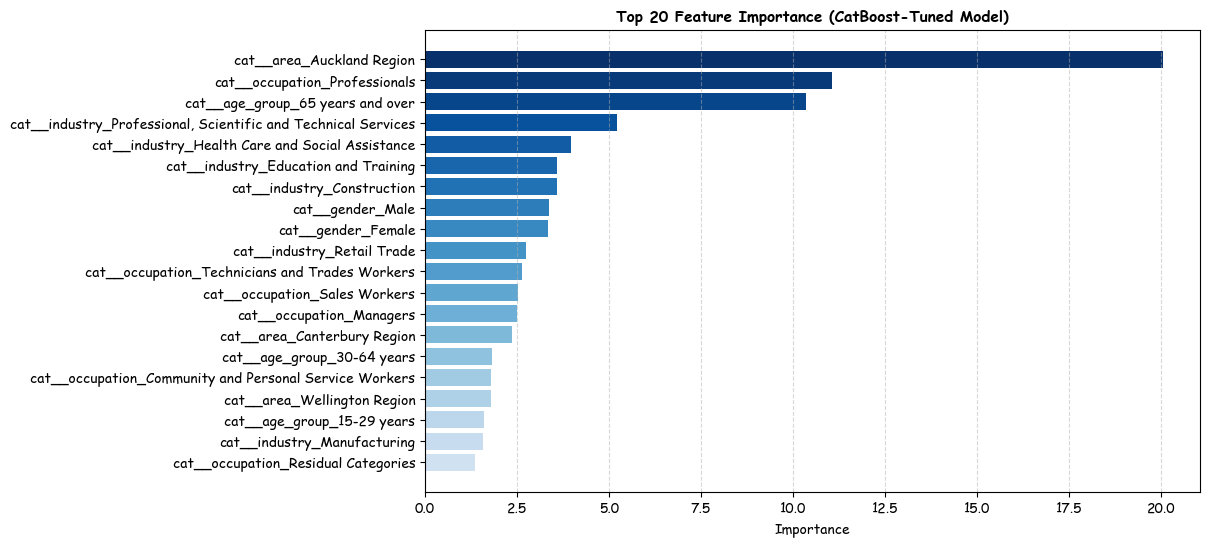

In [98]:
colors = plt.cm.Blues(np.linspace(1, 0.2, len(top20)))

plt.figure(figsize=(10,6))
plt.barh(top20['Feature'], top20['Importance'], color=colors)
plt.grid(axis='x',linestyle='--', alpha=0.5)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importance (CatBoost-Tuned Model)",fontweight='bold', fontsize=11)
plt.show()

## Model Building - Approach 2

***Outlier Removal***

In [134]:
occdf_optmd = occdf.copy()

In [135]:
#function to remove outliers

def remove_outlier(data_in, col_name):
    q1 = data_in[col_name].quantile(0.25)
    q3 = data_in[col_name].quantile(0.75)

    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    data_out = data_in.loc[(data_in[col_name] > fence_low) & (data_in[col_name] < fence_high)]

    return data_out

In [136]:
occdf_optmd_cl = remove_outlier(occdf_optmd,"labour_demand") #Removing of outliers in "labour_demand"

In [137]:
occdf_optmd_cl.shape

(182846, 9)

In [138]:
audit_table_aftr_opt = pd.DataFrame({
    "Metric": [
        "Initial Rows",
        "Initial Columns",
        "Total Rows Removed",
        "Total Columns Removed",
        "Total Area Values Corrected",
        "Total Gender Values Corrected",
        "Total Occupation Values Corrected",
        "Total Outliers Identified",
        "Final Dataset Rows",
        "Final Dataset Columns",
        "Final Dataset Rows - No_Outliers",
        "Final Dataset Columns - No_Outliers"
    ],
    "Value": [
        initial_rows,
        initial_cols,
        dropped_na_count,
        drop_columns_count + dropped_cols_count,
        area_corrected,
        gender_corrected,
        occupation_corrected,
        len(out),
        occdf_cleaned.shape[0],
        occdf_cleaned.shape[1],
        occdf_optmd_cl.shape[0],
        occdf_optmd_cl.shape[1]
    ]
})

audit_table_aftr_opt = audit_table_aftr_opt[['Metric', 'Value']]
audit_table_aftr_opt['Value'] = audit_table_aftr_opt['Value'].apply(lambda x: f"{x:,}" if isinstance(x, (int, float)) else x)

display(Markdown("<span style='font-size:13px; font-weight:bold;'>Data Cleaning and Preprocessing Audit Report - V2</span>"))
audit_table_aftr_opt

<span style='font-size:13px; font-weight:bold;'>Data Cleaning and Preprocessing Audit Report - V2</span>

,Metric,Value
0,Initial Rows,"293,760"
1,Initial Columns,16
2,Total Rows Removed,"76,160"
3,Total Columns Removed,7
4,Total Area Values Corrected,"14,400"
5,Total Gender Values Corrected,"217,600"
6,Total Occupation Values Corrected,"24,000"
7,Total Outliers Identified,"34,754"
8,Final Dataset Rows,"217,600"
9,Final Dataset Columns,9


### Time-Based Split

In [145]:
# Split

train_df = occdf_optmd_cl[occdf_optmd_cl['census_year'] == 2018].copy()
test_df  = occdf_optmd_cl[occdf_optmd_cl['census_year'] == 2023].copy()

X_train = train_df.drop('labour_demand', axis=1)
y_train = train_df['labour_demand']

X_test = test_df.drop('labour_demand', axis=1)
y_test = test_df['labour_demand']

In [146]:
# Encoding

cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [147]:
model_results_ver2 = []

## 1. Decision Tree
***Hyperparameter Tuned - GridSearch Model***

In [148]:
dt_model2 = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_grid = {
    'model__max_depth': [3, 5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 3, 5, 10],
    'model__criterion': ['squared_error', 'friedman_mse']
}

grid_search = GridSearchCV(
    dt_model2,
    param_grid,
    cv=5,
    scoring='r2',   
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_dt_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

dt_pred = best_dt_model.predict(X_test)

dtbestv2_mae  = mean_absolute_error(y_test, dt_pred)
dtbestv2_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dtbestv2_r2   = r2_score(y_test, dt_pred)

model_results_ver2.append({
    'Model': 'Decision Tree - GridSearch_V2',
    'MAE': dtbestv2_mae,
    'RMSE': dtbestv2_rmse,
    'R2': dtbestv2_r2
})

print("\nDecision Tree - GridSearch Tuned Results - V2")
print(f"MAE:  {dtbestv2_mae:.3f}")
print(f"RMSE: {dtbestv2_rmse:.3f}")
print(f"R2:   {dtbestv2_r2:.3f}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best Parameters:
{'model__criterion': 'friedman_mse', 'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

Decision Tree - GridSearch Tuned Results - V2
MAE:  3.142
RMSE: 5.554
R2:   -0.359


## 2. XGBoost
***Hyperparameter Tuned Model***

In [149]:
xgb_model2 = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_model2.fit(X_train, y_train)
xgb_pred = xgb_model2.predict(X_test)

xgbTV2_mae  = mean_absolute_error(y_test, xgb_pred)
xgbTV2_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgbTV2_r2   = r2_score(y_test, xgb_pred)

model_results_ver2.append({
    'Model': 'XGBoost -Tuned V2',
    'MAE': xgbTV2_mae,
    'RMSE': xgbTV2_rmse,
    'R2': xgbTV2_r2
})

print("\nXGBoost Results_Tuned")
print(f"MAE:  {xgbTV2_mae:.3f}")
print(f"RMSE: {xgbTV2_rmse:.3f}")
print(f"R2:   {xgbTV2_r2:.3f}")


XGBoost Results_Tuned
MAE:  3.321
RMSE: 4.959
R2:   -0.084


## 3. Random Forest

In [151]:
rf_model2 = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model2.fit(X_train, y_train)
rf_pred = rf_model2.predict(X_test)

rfV2_mae  = mean_absolute_error(y_test, rf_pred)
rfV2_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rfV2_r2   = r2_score(y_test, rf_pred)

model_results_ver2.append({
    'Model': 'Random Forest - V2',
    'MAE': rfV2_mae,
    'RMSE': rfV2_rmse,
    'R2': rfV2_r2
})

print("\nRandom Forest Results")
print(f"MAE:  {rfV2_mae:.3f}")
print(f"RMSE: {rfV2_rmse:.3f}")
print(f"R2:   {rfV2_r2:.3f}")


Random Forest Results
MAE:  3.127
RMSE: 5.442
R2:   -0.305


## 4. CatBoost
***Hyperparameter Tuned Model***

In [150]:
cat_model2 = Pipeline([
    ('prep', preprocessor),
    ('model', CatBoostRegressor(
        iterations=2000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=5,
        subsample=0.8,
        loss_function='RMSE',
        random_state=42,
        verbose=200,
        early_stopping_rounds=50
    ))
])

cat_model2.fit(X_train, y_train)
cat_pred = cat_model2.predict(X_test)

catTV2_mae  = mean_absolute_error(y_test, cat_pred)
catTV2_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
catTV2_r2   = r2_score(y_test, cat_pred)

model_results_ver2.append({
    'Model': 'CatBoost -Tuned V2',
    'MAE': catTV2_mae,
    'RMSE': catTV2_rmse,
    'R2': catTV2_r2
})

print("\nCatBoost Results - Tuned V2")
print(f"MAE:  {catTV2_mae:.3f}")
print(f"RMSE: {catTV2_rmse:.3f}")
print(f"R2:   {catTV2_r2:.3f}")

0:	learn: 5.2624929	total: 57ms	remaining: 1m 53s
200:	learn: 3.7843935	total: 4.13s	remaining: 36.9s
400:	learn: 3.4543060	total: 8.42s	remaining: 33.6s
600:	learn: 3.2570520	total: 12.4s	remaining: 28.8s
800:	learn: 3.1265304	total: 16.3s	remaining: 24.4s
1000:	learn: 3.0290543	total: 20s	remaining: 20s
1200:	learn: 2.9516952	total: 23.9s	remaining: 15.9s
1400:	learn: 2.8892527	total: 27.5s	remaining: 11.8s
1600:	learn: 2.8353455	total: 31.1s	remaining: 7.74s
1800:	learn: 2.7873893	total: 34.5s	remaining: 3.82s
1999:	learn: 2.7450590	total: 38.4s	remaining: 0us

CatBoost Results - Tuned V2
MAE:  3.443
RMSE: 5.535
R2:   -0.350


## Model Evaluation

In [157]:
results_dfv2  = pd.DataFrame(model_results_ver2)
results_dfv2  = results_dfv2.sort_values(by="RMSE").reset_index(drop=True)

#display(Markdown("<div style="text-align:center"><span style='font-size:13px; font-weight:bold;'>Model Evaluation Metrics</span>"))
display(Markdown("""<span style="font-size:14px; font-weight:bold;">Model Evaluation Metrics - Approach 2</span></div>"""))
results_dfv2

<span style="font-size:14px; font-weight:bold;">Model Evaluation Metrics - Approach 2</span></div>

,Model,MAE,RMSE,R2
0,XGBoost -Tuned V2,3.321029,4.959146,-0.083735
1,Random Forest - V2,3.127105,5.442351,-0.305216
2,CatBoost -Tuned V2,3.443385,5.535003,-0.350035
3,Decision Tree - GridSearch_V2,3.142400,5.553952,-0.359295


## Model Building - Approach 3
***CatBoost Tuned Model (80:20 Train - Test Split)***

In [99]:
occdf_fl = occdf.copy()

In [100]:
X_full = occdf_fl.drop('labour_demand', axis=1)
y_full = occdf_fl['labour_demand']

In [101]:
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X_full,y_full,test_size=0.2,random_state=42)

In [103]:
cat_model_hy.fit(X_train, y_train)

cat_pred = cat_model_hy.predict(X_test)

cat_full_mae = mean_absolute_error(y_test, cat_pred)
cat_full_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
cat_full_r2 = r2_score(y_test, cat_pred)

print("\nCatBoost Hyperparameter Tuned Model - 80:20 Train - Test Split")
print(f"MAE : {cat_full_mae:.3f}")
print(f"RMSE: {cat_full_rmse:.3f}")
print(f"R²  : {cat_full_r2:.3f}")


0:	learn: 104.4671521	total: 32.9ms	remaining: 1m 5s
200:	learn: 64.5299870	total: 11.2s	remaining: 1m 39s
400:	learn: 55.3496527	total: 22.7s	remaining: 1m 30s
600:	learn: 49.7335767	total: 36s	remaining: 1m 23s
800:	learn: 46.0215419	total: 47.9s	remaining: 1m 11s
1000:	learn: 43.0299856	total: 1m	remaining: 59.9s
1200:	learn: 40.6218906	total: 1m 12s	remaining: 47.9s
1400:	learn: 38.6155936	total: 1m 24s	remaining: 35.9s
1600:	learn: 36.9906980	total: 1m 36s	remaining: 24s
1800:	learn: 35.6419987	total: 1m 48s	remaining: 11.9s
1999:	learn: 34.4622460	total: 2m	remaining: 0us

CatBoost Hyperparameter Tuned Model - 80:20 Train - Test Split
MAE : 13.592
RMSE: 43.294
R²  : 0.870


In [112]:
comparison_df = pd.DataFrame([
    {
        "Model": "CatBoost - Tuned",
        "Method": "TimeSeries CV",
        "MAE": -np.mean(cv_results["test_MAE"]),
        "RMSE": -np.mean(cv_results["test_RMSE"]),
        "R2": np.mean(cv_results["test_R2"])
    },
    {
        "Model": "CatBoost - Tuned",
        "Method": "80:20 Hold-out",
        "MAE": cat_full_mae,
        "RMSE": cat_full_rmse,
        "R2": cat_full_r2
    },
    {
        "Model": "CatBoost - Tuned",
        "Method": "Temporal Hold-out (2018–2023 split)",
        "MAE": cathy_mae,
        "RMSE": cathy_rmse,
        "R2": cathy_r2
    }    
])

comparison_df = comparison_df.sort_values(by="R2", ascending=False).reset_index(drop=True)
display(Markdown("""<span style="font-size:14px; font-weight:bold;">Model Performance Comparison (Cross-Validation and Temporal Hold-out)</span></div>"""))
comparison_df


<span style="font-size:14px; font-weight:bold;">Model Performance Comparison (Cross-Validation and Temporal Hold-out)</span></div>

,Model,Method,MAE,RMSE,R2
0,CatBoost - Tuned,80:20 Hold-out,13.591623,43.294052,0.869509
1,CatBoost - Tuned,TimeSeries CV,14.191728,44.341411,0.828115
2,CatBoost - Tuned,Temporal Hold-out (2018–2023 split),20.471064,65.978256,0.570251


## Predicting for 2028 with CatBoost 
***(Hyperparameter Tuned Model)***

***Making 2028 Dataset***

In [113]:
occdf_2028 = occdf_fl[occdf_fl['census_year'] == 2023].copy()

In [114]:
occdf_2028['census_year'] = 2028

In [115]:
X_2028 = occdf_2028.drop('labour_demand', axis=1, errors='ignore')

***Making Training Dataset with 2018 + 2023***

In [116]:
train_df = occdf_fl[occdf_fl['census_year'].isin([2018, 2023])].copy()

In [117]:
X_train_full = train_df.drop('labour_demand', axis=1)
y_train_full = train_df['labour_demand']

In [118]:
cat_model_hy.fit(X_train_full, y_train_full)

0:	learn: 107.4155563	total: 37.1ms	remaining: 1m 14s
200:	learn: 65.4205922	total: 13.3s	remaining: 1m 58s
400:	learn: 56.0201428	total: 27.2s	remaining: 1m 48s
600:	learn: 49.9038920	total: 41s	remaining: 1m 35s
800:	learn: 45.9248295	total: 54.7s	remaining: 1m 21s
1000:	learn: 42.8237008	total: 1m 8s	remaining: 1m 8s
1200:	learn: 40.3204921	total: 1m 22s	remaining: 55.1s
1400:	learn: 38.3290372	total: 1m 37s	remaining: 41.5s
1600:	learn: 36.6527320	total: 1m 51s	remaining: 27.7s
1800:	learn: 35.2659077	total: 2m 5s	remaining: 13.9s
1999:	learn: 33.9764367	total: 2m 20s	remaining: 0us


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['area', 'island', 'occupation', 'industry', 'age', 'age_group',
       'gender'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['census_year'], dtype='object'))])),
                ('model',
                 CatBoostRegressor(depth=8, early_stopping_rounds=50, iterations=2000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_state=42, subsample=0.8, verbose=200))])

In [120]:
print(cat_model_hy.score(X_train_full, y_train_full))

0.9018995251780086


In [124]:
print(f"Training score: {cat_model_hy.score(X_train_full, y_train_full):.2f}")

Training score: 0.90


In [144]:
occdf_2028['predicted_labour_demand'] = cat_model_hy.predict(X_2028)

occdf_2028.to_csv("Labour_demand_predictions_2028_Final_Output.csv", index=False)

print("Prediction for 2028 completed successfully.")
print("Final Output CSV has been copied.")

Prediction for 2028 completed successfully.
Final Output CSV has been copied.
